In [ ]:
import pandas as pd

from se_analysis import shading

In [ ]:
# Sundance, CO
lat = 39.418908
lon = -104.450278
rod_len = 1.5 # feet
tower_ht = 8
boom_len = 4
rod_ht = tower_ht + rod_len

# Lightning rod shadow on the pyranometer

The tower carries the pyranometer out on a boom and its lightning rod straight up
off the top. When the sun lines up with the boom and sits low enough, the rod is
between the sun and the sensor and the trace takes a notch.

Two things have to be true at once, and both come out of the geometry:

- **Azimuth.** The sun has to be within a fraction of a degree of the boom's own
  bearing -- the shadow is as narrow as the rod.
- **Elevation.** The rod's tip throws its shadow `rod_len / tan(elevation)` out
  from the mast, so the sun has to be low enough for that to reach `boom_len`.
  Above `arctan(rod_len / boom_len)` it never can, on any date.

`se_analysis.shading` solves the two together, as one segment against one point,
and reports the fraction of the solar disk the rod covers rather than a yes/no --
a half-inch rod seen from four feet subtends about the same angle as the sun, so
the edges of the event are partial.

In [3]:
# The boom runs east-west, which still leaves it pointing one way, and that
# decides whether the notch lands in the afternoon (boom east, sun behind it) or
# the morning (boom west). Both are checked below.
boom_azimuth = 270  # degrees clockwise from true north; 90 = east
tz = "America/Denver"  # so the answers read as local clock time

## The one number that decides whether this site has the problem

Above this sun elevation the rod's shadow falls short of the boom no matter where
the sun is, so nothing else matters.

In [4]:
grazing = shading.grazing_elevation(rod_len=rod_len, boom_len=boom_len)
print(f"shadow can only reach the sensor with the sun below {grazing:.2f}°")

shadow can only reach the sensor with the sun below 20.56°


## One date

`shadow_track` walks a single day at 10-second steps -- the event is minutes
long, so a coarser step can walk straight over the peak. `shadow_windows`
reduces that to the intervals worth looking for in the data.

In [5]:
track = shading.shadow_track(
    "2026-04-15",
    lat,
    lon,
    tz=tz,
    tower_ht=tower_ht,
    rod_len=rod_len,
    boom_len=boom_len,
    boom_azimuth=boom_azimuth,
)
shading.shadow_windows(track)

,start,end,duration,peak,elevation,azimuth
0,2026-04-15 07:43:20-06:00,2026-04-15 07:50:30-06:00,0 days 00:07:10,1.0,15.764469,89.998207


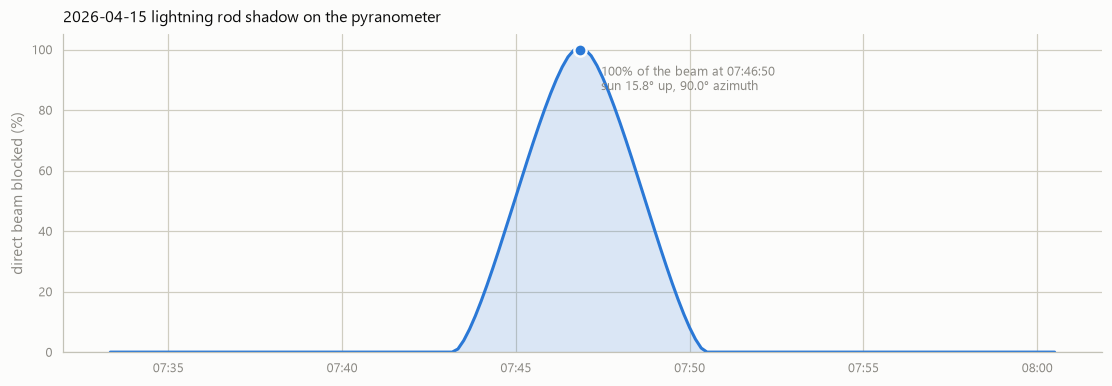

In [6]:
shading.plot_track(track, title="2026-04-15")

## Through the year

The sun reaches due west above the horizon only between the equinoxes, and the
higher it is when it gets there the further the shadow falls short. That confines
the whole problem to two bands either side of the equinoxes.

`shadow_season` walks the span in one pass at 1-minute steps -- coarse against a
7-minute notch, so read `peak` and `minutes` as the shape of the season and
re-run `shadow_track` on any date that matters.

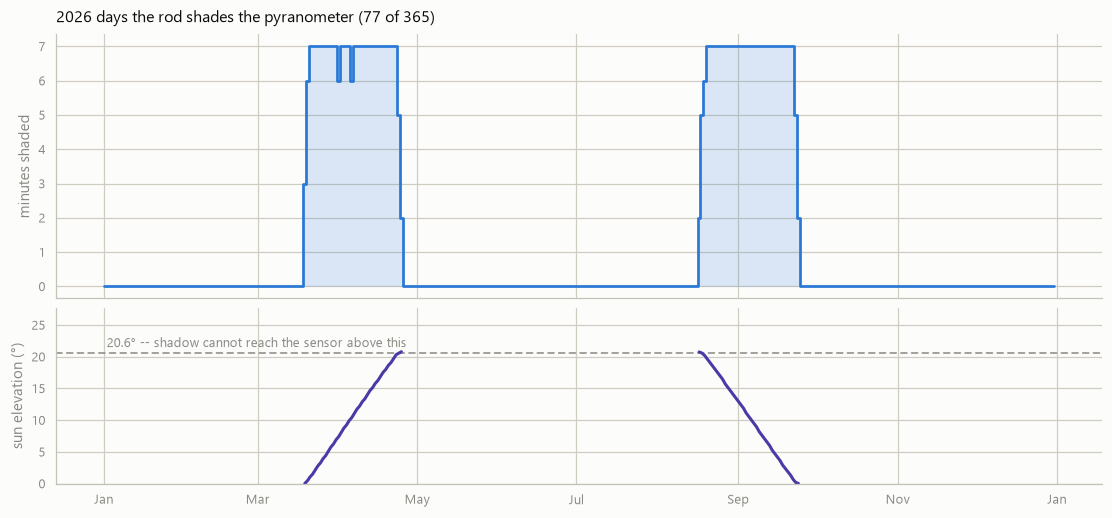

In [7]:
season = shading.shadow_season(
    "2026-01-01",
    "2026-12-31",
    lat,
    lon,
    tz=tz,
    tower_ht=tower_ht,
    rod_len=rod_len,
    boom_len=boom_len,
    boom_azimuth=270,
)
shading.plot_season(season, rod_len=rod_len, boom_len=boom_len, title="2026")

In [8]:
# The affected dates, and the local time to go looking at.
affected = season[season["minutes"] > 0]
print(f"{len(affected)} of {len(season)} days are affected")
for _, band in affected.groupby((affected.index.to_series().diff() > pd.Timedelta("1D")).cumsum()):
    print(
        f"{band.index[0]:%b %d} to {band.index[-1]:%b %d}: "
        f"{band['at'].dt.strftime('%H:%M').iloc[0]} drifting to "
        f"{band['at'].dt.strftime('%H:%M').iloc[-1]} local, "
        f"sun {band['elevation'].min():.0f}-{band['elevation'].max():.0f}° up"
    )

77 of 365 days are affected
Mar 19 to Apr 25: 07:04 drifting to 08:00 local, sun 0-21° up
Aug 17 to Sep 24: 08:06 drifting to 06:49 local, sun 0-21° up


## Which way the boom points

The two directions are mirror images: an east boom is shaded in the evening, a
west boom in the morning, on the same dates.

In [9]:
for azimuth, name in ((90, "east"), (270, "west")):
    windows = shading.shadow_windows(
        shading.shadow_track(
            "2026-04-15", lat, lon, tz=tz,
            tower_ht=tower_ht, rod_len=rod_len, boom_len=boom_len,
            boom_azimuth=azimuth,
        )
    )
    row = windows.iloc[0]
    print(
        f"boom {name:<5} {row['start']:%H:%M:%S}-{row['end']:%H:%M:%S} local, "
        f"peak {row['peak']:.0%} of the beam, sun {row['elevation']:.1f}° up"
    )

boom east  18:04:30-18:11:30 local, peak 100% of the beam, sun 16.0° up
boom west  07:43:20-07:50:30 local, peak 100% of the beam, sun 15.8° up


## How much the assumed rod diameter matters

The rod's thickness is the one input that was assumed rather than measured, and
it sets how deep the notch goes. It does not change *whether* there is one:
even quarter-inch stock takes most of the beam.

In [10]:
for inches in (0.25, 0.375, 0.5, 0.625, 0.75):
    windows = shading.shadow_windows(
        shading.shadow_track(
            "2026-04-15", lat, lon, tz=tz,
            tower_ht=tower_ht, rod_len=rod_len, boom_len=boom_len,
            boom_azimuth=boom_azimuth, rod_diameter=inches / 12,
        )
    )
    row = windows.iloc[0]
    print(
        f'{inches:>5}" rod: peak {row["peak"]:>4.0%} of the beam, '
        f"{row['duration'].total_seconds() / 60:.1f} min over threshold"
    )

 0.25" rod: peak  65% of the beam, 5.2 min over threshold
0.375" rod: peak  90% of the beam, 6.2 min over threshold
  0.5" rod: peak 100% of the beam, 7.2 min over threshold
0.625" rod: peak 100% of the beam, 7.8 min over threshold
 0.75" rod: peak 100% of the beam, 8.8 min over threshold
